In [1]:
from __future__ import annotations

import json
import os
import re
from collections.abc import Mapping
from functools import partial
from pathlib import Path
from types import MappingProxyType
from typing import Any, Optional

import numpy as np
import pandas as pd
from dask_image.imread import imread
from spatialdata import SpatialData
from spatialdata._logging import logger
from spatialdata.models import Image2DModel, ShapesModel, TableModel
from spatialdata.transformations.transformations import Identity, Scale
from xarray import DataArray

from spatialdata_io._constants._constants import VisiumKeys
from spatialdata_io._docs import inject_docs
from spatialdata_io.readers._utils._utils import _read_counts

__all__ = ["visium"]

# Modification of visium from spatialdata-io
def visium(
    path: str | Path,
    dataset_id: Optional[str] = None,
    counts_file: str = VisiumKeys.COUNTS_FILE,
    fullres_image_file: Optional[str | Path] = None,
    tissue_positions_file: Optional[str | Path] = None,
    scalefactors_file: Optional[str | Path] = None,
    imread_kwargs: Mapping[str, Any] = MappingProxyType({}),
    image_models_kwargs: Mapping[str, Any] = MappingProxyType({}),
    **kwargs: Any,
) -> SpatialData:
    """
    Read *10x Genomics* Visium formatted dataset.

    This function reads the following files:

        - ``(<dataset_id>_)`{vx.COUNTS_FILE!r}```: Counts and metadata file.
        - ``{vx.IMAGE_HIRES_FILE!r}``: High resolution image.
        - ``{vx.IMAGE_LOWRES_FILE!r}``: Low resolution image.
        - ``{vx.SCALEFACTORS_FILE!r}``: Scalefactors file.
        - ``{vx.SPOTS_FILE_1!r}`` (SpaceRanger 1) or ``{vx.SPOTS_FILE_2!r}`` (SpaceRanger 2):
            Spots positions file.
        - ``fullres_image_file``: large microscopy image used as input for space ranger.

    .. seealso::

        - `Space Ranger output <https://support.10xgenomics.com/spatial-gene-expression/software/pipelines/latest/output/overview>`_.

    Parameters
    ----------
    path
        Path to the directory containing the data.
    dataset_id
        Dataset identifier to name the constructed `SpatialData` elements. The reader will try to infer it from the
        ``{vx.COUNTS_FILE!r}`` file name. If the file name does not contain the dataset id, it will try to infer it from the metadata, it needs to be provided.
    counts_file
        Name of the counts file. Use only if counts is not in `h5` format.
    fullres_image_file
        Path to the full-resolution image.
    tissue_positions_file
        Path to the tissue positions file.
    scalefactors_file
        Path to the scalefactors file.
    imread_kwargs
        Keyword arguments passed to :func:`dask_image.imread.imread`.
    image_models_kwargs
        Keyword arguments passed to :class:`spatialdata.models.Image2DModel`.

    Returns
    -------
    :class:`spatialdata.SpatialData`
    """
    path = Path(path)
    imread_kwargs = dict(imread_kwargs)
    image_models_kwargs = dict(image_models_kwargs)
    # try to infer library_id from the counts file
    library_id = None
    try:
        patt = re.compile(f".*{VisiumKeys.COUNTS_FILE}")
        first_file = [i for i in os.listdir(path) if patt.match(i)][0]

        if f"_{VisiumKeys.COUNTS_FILE}" in first_file:
            library_id = first_file.replace(f"_{VisiumKeys.COUNTS_FILE}", "")
            counts_file = f"{library_id}_{VisiumKeys.COUNTS_FILE}"
        elif VisiumKeys.COUNTS_FILE == first_file:
            library_id = None
            counts_file = VisiumKeys.COUNTS_FILE
        else:
            raise ValueError(
                f"Cannot determine the library_id. Expecting a file with format (<library_id>_){VisiumKeys.COUNTS_FILE}"
                f". If the files have been renamed you may need to specify their file names (not their paths), with "
                f"some of the following arguments: `counts_file`, `fullres_image_file`, `tissue_positions_file`, "
                f"`scalefactors_file` arguments."
            )
    except IndexError as e:
        if counts_file is None:
            logger.error(
                f"{e}. \nError is due to the fact that the library id could not be found, if the counts file is `.mtx` (or else), Please provide a `counts_file`.",
            )
            raise e
    assert counts_file is not None

    if library_id is None and dataset_id is None:
        raise ValueError("Cannot determine the `library_id`. Please provide `dataset_id`.")

    if dataset_id is not None:
        if dataset_id != library_id and library_id is not None:
            logger.warning(
                f"`dataset_id: {dataset_id}` does not match `library_id: {library_id}`. `dataset_id: {dataset_id}` "
                f"will be used to build SpatialData."
            )
        library_id = dataset_id
    else:
        dataset_id = library_id
    assert dataset_id is not None

    # Yhe second element of the returned tuple is the full library as contained in the metadata of
    # VisiumKeys.COUNTS_FILE. For instance for the spatialdata-sandbox/visium dataset it is:
    #     spaceranger100_count_30458_ST8059048_mm10-3_0_0_premrna
    # We discard this value and use the one inferred from the filename of VisiumKeys.COUNTS_FILE, or the one provided by
    # the user in dataset_id
    adata, _ = _read_counts(path, counts_file=counts_file, library_id=library_id, **kwargs)

    # Read parquet file
    if (path / "spatial" / "tissue_positions.parquet").exists(): 
        read_coords = partial(pd.read_parquet)
        tissue_positions_file = path / "spatial" / "tissue_positions.parquet"
    else:
        raise ValueError(f"Cannot find `tissue_positions` file in `{path}`.")
    coords = read_coords(tissue_positions_file).set_index("barcode")

    # to handle spaceranger_version < 2.0.0, where no column names are provided
    # in fact, from spaceranger 2.0.0, the column names are provided in the file, and
    # are "pxl_col_in_fullres", "pxl_row_in_fullres" are inverted.
    # But, in the case of CytAssist, the column names provided but the image is flipped
    # so we need to invert the columns.
    if "in_tissue" not in coords.columns or "CytAssist" in str(fullres_image_file):
        coords.columns = ["in_tissue", "array_row", "array_col", "pxl_col_in_fullres", "pxl_row_in_fullres"]

    adata.obs = pd.merge(adata.obs, coords, how="left", left_index=True, right_index=True)
    coords = adata.obs[[VisiumKeys.SPOTS_X, VisiumKeys.SPOTS_Y]].values
    adata.obsm["spatial"] = coords
    adata.obs = pd.DataFrame(adata.obs)
    adata.obs.drop(columns=[VisiumKeys.SPOTS_X, VisiumKeys.SPOTS_Y], inplace=True)
    adata.obs["spot_id"] = np.arange(len(adata))
    adata.var_names_make_unique()
    if (path / "spatial" / VisiumKeys.SCALEFACTORS_FILE).exists() or (
        scalefactors_file is not None and (path / scalefactors_file).exists()
    ):
        scalefactors_file = (
            path / "spatial" / VisiumKeys.SCALEFACTORS_FILE if scalefactors_file is None else path / scalefactors_file
        )
        scalefactors = json.loads(scalefactors_file.read_bytes())

    transform_original = Identity()
    transform_lowres = Scale(
        np.array([scalefactors[VisiumKeys.SCALEFACTORS_LOWRES], scalefactors[VisiumKeys.SCALEFACTORS_LOWRES]]),
        axes=("y", "x"),
    )
    transform_hires = Scale(
        np.array([scalefactors[VisiumKeys.SCALEFACTORS_HIRES], scalefactors[VisiumKeys.SCALEFACTORS_HIRES]]),
        axes=("y", "x"),
    )
    shapes = {}
    circles = ShapesModel.parse(
        coords,
        geometry=0,
        radius=scalefactors["spot_diameter_fullres"] / 2.0,
        index=adata.obs["spot_id"].copy(),
        transformations={
            "global": transform_original,
            "downscaled_hires": transform_hires,
            "downscaled_lowres": transform_lowres,
        },
    )
    shapes[dataset_id] = circles
    adata.obs["region"] = dataset_id
    table = TableModel.parse(adata, region=dataset_id, region_key="region", instance_key="spot_id")

    images = {}
    if fullres_image_file is not None:
        fullres_image_file = path / Path(fullres_image_file)
        if fullres_image_file.exists():
            if "MAX_IMAGE_PIXELS" in imread_kwargs:
                from PIL import Image as ImagePIL

                ImagePIL.MAX_IMAGE_PIXELS = imread_kwargs.pop("MAX_IMAGE_PIXELS")
            full_image = imread(fullres_image_file, **imread_kwargs).squeeze().transpose(2, 0, 1)
            full_image = DataArray(full_image, dims=("c", "y", "x"))
            images[dataset_id + "_full_image"] = Image2DModel.parse(
                full_image,
                scale_factors=[2, 2, 2, 2],
                transformations={"global": transform_original},
                **image_models_kwargs,
            )
        else:
            logger.warning(f"File {fullres_image_file} does not exist, skipping...")

    if (path / VisiumKeys.IMAGE_HIRES_FILE).exists():
        image_hires = imread(path / VisiumKeys.IMAGE_HIRES_FILE, **imread_kwargs).squeeze().transpose(2, 0, 1)
        image_hires = DataArray(image_hires, dims=("c", "y", "x"))
        images[dataset_id + "_hires_image"] = Image2DModel.parse(
            image_hires, transformations={"downscaled_hires": Identity()}
        )
    if (path / VisiumKeys.IMAGE_LOWRES_FILE).exists():
        image_lowres = imread(path / VisiumKeys.IMAGE_LOWRES_FILE, **imread_kwargs).squeeze().transpose(2, 0, 1)
        image_lowres = DataArray(image_lowres, dims=("c", "y", "x"))
        images[dataset_id + "_lowres_image"] = Image2DModel.parse(
            image_lowres, transformations={"downscaled_lowres": Identity()}
        )

    return SpatialData(images=images, shapes=shapes, table=table)

In [2]:
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
from napari_spatialdata import Interactive

from spatialdata.transformations import (
    Affine,
    Identity,
    MapAxis,
    Scale,
    Sequence,
    Translation,
    get_transformation,
    get_transformation_between_coordinate_systems,
    set_transformation,
)

import matplotlib.patches as patches
from matplotlib import pyplot as plt

In [3]:

filepath = "/home/chananchidas/topsecret/spaceranger/binned_outputs/"

sdata = visium(filepath + "square_048um/",
                               dataset_id = 'visium-hd')

INFO     reading /home/chananchidas/topsecret/spaceranger/binned_outputs/square_048um/filtered_feature_bc_matrix.h5


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_161907/1485599302.py:185: UserWarning: Converting `region_key: region` to categorical dtype.
  table = TableModel.parse(adata, region=dataset_id, region_key="region", instance_key="spot_id")


In [4]:
sdata

SpatialData object with:
├── Images
│     ├── 'visium-hd_hires_image': SpatialImage[cyx] (3, 2000, 1431)
│     └── 'visium-hd_lowres_image': SpatialImage[cyx] (3, 600, 429)
├── Shapes
│     └── 'visium-hd': GeoDataFrame shape: (15054, 2) (2D shapes)
└── Table
      └── AnnData object with n_obs × n_vars = 15054 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatialdata_attrs'
    obsm: 'spatial': AnnData (15054, 18085)
with coordinate systems:
▸ 'downscaled_hires', with elements:
        visium-hd_hires_image (Images), visium-hd (Shapes)
▸ 'downscaled_lowres', with elements:
        visium-hd_lowres_image (Images), visium-hd (Shapes)
▸ 'global', with elements:
        visium-hd (Shapes)

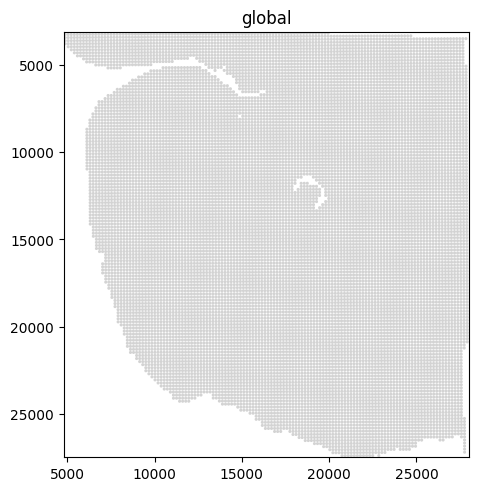

In [5]:
# Check points
sdata.pl.render_shapes().pl.show(coordinate_systems="global")

If you just render the images with the shapes, there will be a mismatch.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


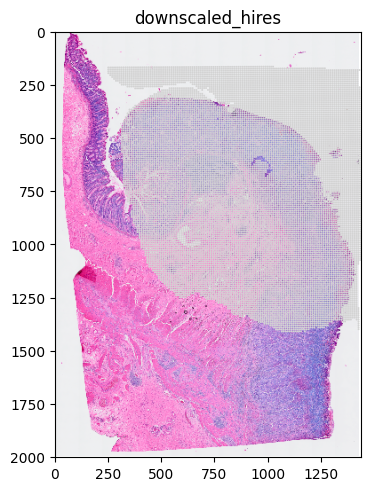

In [6]:
sdata.pl.render_images().pl.render_shapes().pl.show(coordinate_systems="downscaled_hires")

A transformation of both the shapes and the image is therefore necessary. The scaling factors for the image can be obtained from the `scalefactors_json.json` file. The information is also stored in the object, but we must retrieve it before we apply transformations to the image.

In [7]:
coord_system = 'downscaled_hires' # 'downscaled_hires ,'downscaled_lowres', or 'global'

# Get the image scale factor to match with points
image_scale_transform = get_transformation(sdata.shapes["visium-hd"], coord_system).inverse()

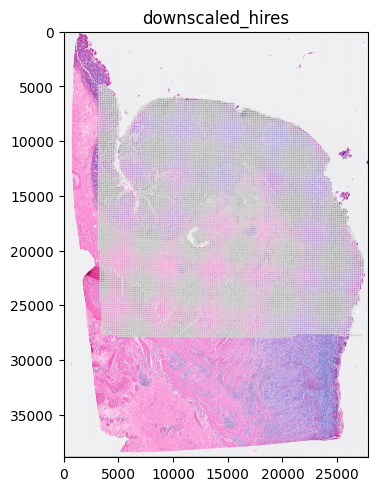

In [8]:
# For the shapes, we need to flip the y-axis and map x to y and y to x
flip_transform = Scale([1, -1], axes=("y", "x"))  
map_axis = MapAxis({"x": "y", "y": "x"})          

# Set shape transformations
set_transformation(sdata.shapes["visium-hd"], flip_transform, to_coordinate_system=coord_system)
set_transformation(sdata.shapes["visium-hd"], map_axis, to_coordinate_system=coord_system)

# If coord_system is 'downscaled_hires' or 'downscaled_lowres', scale the image
if coord_system != 'global':
    img_name = "visium-hd_" + coord_system.split('_')[1] + "_image"
    set_transformation(sdata.images[img_name], image_scale_transform, to_coordinate_system=coord_system)
    sdata.pl.render_images().pl.render_shapes().pl.show(coordinate_systems=coord_system)
else:
    sdata.pl.render_shapes().pl.show(coordinate_systems=coord_system)



In [9]:
# Test in napari
Interactive(sdata)

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/napari_spatialdata/_sdata_widgets.py:127: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if type(sdata.shapes[original_name].iloc[0][0]) == shapely.geometry.point.Point:
2024-03-05 16:41:18.568 | INFO     | napari_spatialdata._view:_on_layer_update:214 - Updating layer.
2024-03-05 16:41:18.613 | INFO     | napari_spatialdata._view:_on_layer_update:214 - Updating layer.
2024-03-05 16:41:27.321 | INFO     | napari_spatialdata._view:_on_layer_update:214 - Updating layer.
2024-03-05 16:41:27.426 | INFO     | napari_spatialdata._view:_on_layer_update:214 - Updating layer.
